# K-Means Feature Space Analysis: SST vs Chlorophyll-a vs SSL + Circular Month Encoding

This notebook extends the SSL K-means workflow by adding continuous month encoding and circular month features (`month_sin`, `month_cos`) to clustering.

In [1]:
# Imports
import pickle
import warnings
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap, BoundaryNorm

In [2]:
# Load dataset
with open(r'E:\satdata\Custom\yucatan_sst_chlor_cdomslope_ssl_bathy_2010-2019_v3.pkl', 'rb') as f:
    data = pickle.load(f)

df = data['data']
metadata = data['metadata']

print('Dataset loaded successfully!')
print(f'Date range: {df.index.min()} to {df.index.max()}')
print(f'Total records: {len(df)}')

Dataset loaded successfully!
Date range: 2010-01-01 00:00:00 to 2020-01-01 00:00:00
Total records: 3662


In [3]:
def continuous_month(ts):
    # Halfway between Jan and Feb = 1.5
    return ts.month + (ts.day - 1) / ts.days_in_month


def month_to_circular(month_cont):
    angle = 2 * np.pi * ((month_cont - 1.0) / 12.0)
    return np.sin(angle), np.cos(angle)

In [4]:
# Extract all valid pixel samples and build feature vectors
sst_values = []
chlor_values = []
ssl_values = []
month_cont_values = []
month_sin_values = []
month_cos_values = []

for date_idx, row in df.iterrows():
    month_cont = continuous_month(date_idx)
    month_sin, month_cos = month_to_circular(month_cont)

    sst_grid = row['sst']
    chlor_grid = row['chlorophyll']
    ssl_grid = row['ssl']

    if sst_grid is None or chlor_grid is None or ssl_grid is None:
        continue
    if isinstance(sst_grid, float) and np.isnan(sst_grid):
        continue
    if isinstance(chlor_grid, float) and np.isnan(chlor_grid):
        continue
    if isinstance(ssl_grid, float) and np.isnan(ssl_grid):
        continue

    sst_array = np.array(sst_grid, dtype=float)
    chlor_array = np.array(chlor_grid, dtype=float)
    ssl_array = np.array(ssl_grid, dtype=float)

    ssl_nan_mask = np.isnan(ssl_array)
    if not ssl_nan_mask.all():
        ssl_filled = ssl_array.copy()
        ssl_filled[ssl_nan_mask] = np.nanmean(ssl_array)
        ssl_blurred = gaussian_filter(ssl_filled, sigma=2.0)
        ssl_blurred[ssl_nan_mask] = np.nan
        ssl_array = ssl_blurred

    sst_flat = sst_array.flatten()
    chlor_flat = chlor_array.flatten()
    ssl_flat = ssl_array.flatten()

    valid_mask = ~np.isnan(sst_flat) & ~np.isnan(chlor_flat) & ~np.isnan(ssl_flat) & (chlor_flat > 0)
    n_valid = int(np.sum(valid_mask))
    if n_valid == 0:
        continue

    sst_values.extend(sst_flat[valid_mask])
    chlor_values.extend(chlor_flat[valid_mask])
    ssl_values.extend(ssl_flat[valid_mask])
    month_cont_values.extend([month_cont] * n_valid)
    month_sin_values.extend([month_sin] * n_valid)
    month_cos_values.extend([month_cos] * n_valid)

sst_values = np.array(sst_values)
chlor_values = np.array(chlor_values)
ssl_values = np.array(ssl_values)
month_cont_values = np.array(month_cont_values)
month_sin_values = np.array(month_sin_values)
month_cos_values = np.array(month_cos_values)

print(f'Total valid data points before subsampling: {len(sst_values):,}')
max_points = 1_000_000
if len(sst_values) > max_points:
    np.random.seed(42)
    random_indices = np.random.choice(len(sst_values), size=max_points, replace=False)
    sst_values = sst_values[random_indices]
    chlor_values = chlor_values[random_indices]
    ssl_values = ssl_values[random_indices]
    month_cont_values = month_cont_values[random_indices]
    month_sin_values = month_sin_values[random_indices]
    month_cos_values = month_cos_values[random_indices]

print(f'Continuous month range: {month_cont_values.min():.3f} to {month_cont_values.max():.3f}')

Total valid data points before subsampling: 60,419,911
Continuous month range: 1.000 to 12.968


In [5]:
# Train K-means with circular month features
chlor_log = np.log10(chlor_values)
features = np.column_stack([
    chlor_log,
    sst_values,
    ssl_values,
    month_sin_values,
    month_cos_values,
])

print(f'Feature matrix shape: {features.shape}')
print('Features: [log10(Chlor), SST, SSL, month_sin, month_cos]')

scaler = StandardScaler()
features_z = scaler.fit_transform(features)

n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(features_z)

pca = PCA(n_components=2)
features_pca = pca.fit_transform(features_z)
print(f'PCA variance explained: {100*pca.explained_variance_ratio_.sum():.1f}%')

Feature matrix shape: (1000000, 5)
Features: [log10(Chlor), SST, SSL, month_sin, month_cos]
PCA variance explained: 67.4%


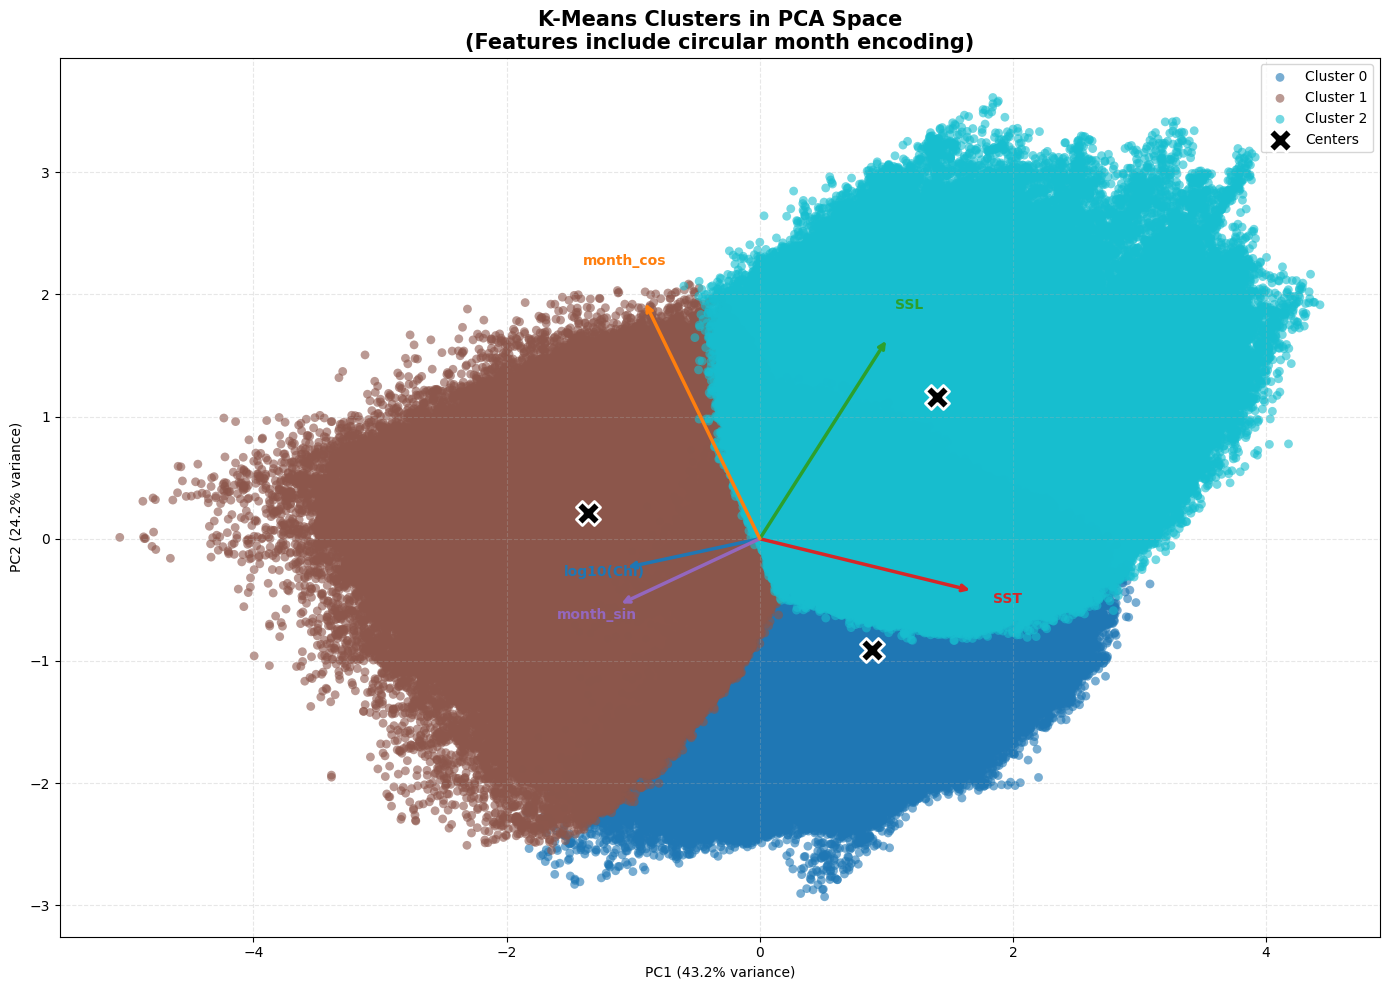

In [6]:
# PCA cluster visualization
fig, ax = plt.subplots(figsize=(14, 10))
cmap = plt.get_cmap('tab10', n_clusters)
colors = [cmap(i) for i in range(n_clusters)]

for i in range(n_clusters):
    mask = cluster_labels == i
    ax.scatter(features_pca[mask, 0], features_pca[mask, 1], c=[colors[i]], s=40, alpha=0.6, edgecolors='none', label=f'Cluster {i}')

centers_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(centers_pca[:, 0], centers_pca[:, 1], c='black', marker='X', s=300, edgecolors='white', linewidths=2, zorder=5, label='Centers')

x_range = features_pca[:, 0].max() - features_pca[:, 0].min()
y_range = features_pca[:, 1].max() - features_pca[:, 1].min()
arrow_scale = min(x_range, y_range) * 0.4
loading_feature_names = ['log10(Chl)', 'SST', 'SSL', 'month_sin', 'month_cos']
loading_colors = ['tab:blue', 'tab:red', 'tab:green', 'tab:purple', 'tab:orange']
for j, (fname, fcolor) in enumerate(zip(loading_feature_names, loading_colors)):
    dx = pca.components_[0, j] * arrow_scale
    dy = pca.components_[1, j] * arrow_scale
    ax.annotate('', xy=(dx, dy), xytext=(0, 0), arrowprops=dict(arrowstyle='->', color=fcolor, lw=2.5, shrinkA=0, shrinkB=0))
    ax.text(dx * 1.18, dy * 1.18, fname, color=fcolor, fontsize=10, fontweight='bold', ha='center', va='center')

ax.set_xlabel(f'PC1 ({100*pca.explained_variance_ratio_[0]:.1f}% variance)')
ax.set_ylabel(f'PC2 ({100*pca.explained_variance_ratio_[1]:.1f}% variance)')
ax.set_title('K-Means Clusters in PCA Space\n(Features include circular month encoding)', fontsize=15, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
ax.legend(loc='best')
plt.tight_layout()
plt.show()

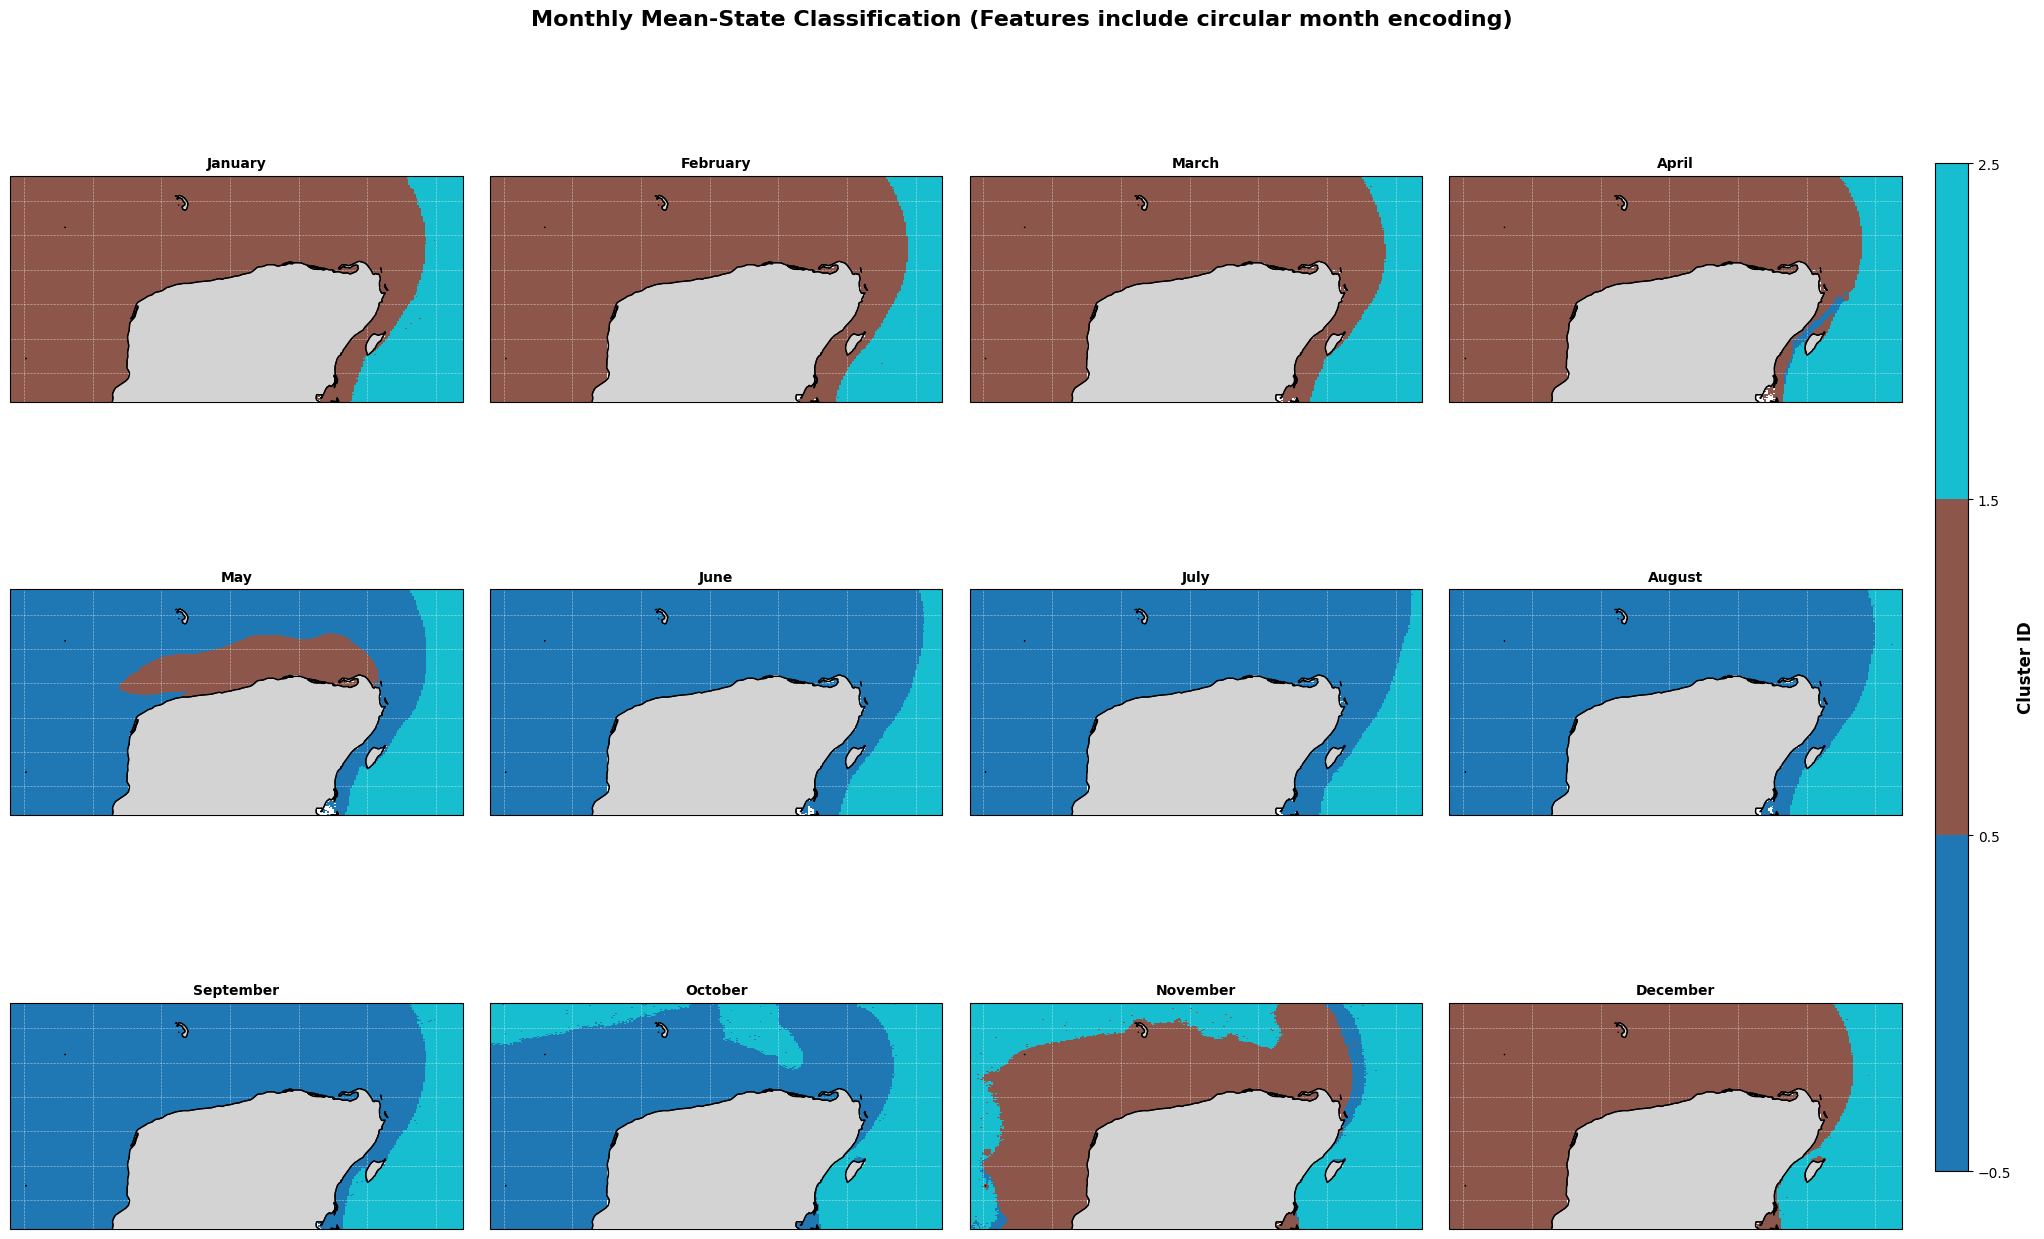

In [7]:
# Monthly mean-state cluster maps (Jan-Dec) with circular month features
month_names_full = ['January', 'February', 'March', 'April', 'May', 'June',
                    'July', 'August', 'September', 'October', 'November', 'December']
lon_centers = np.array(metadata['lon_centers'])
lat_centers = np.array(metadata['lat_centers'])
if lon_centers.ndim == 1 and lat_centers.ndim == 1:
    lon_grid_2d, lat_grid_2d = np.meshgrid(lon_centers, lat_centers)
else:
    lon_grid_2d, lat_grid_2d = lon_centers, lat_centers

lat_min, lon_min = 19.57871, -92.20216
lat_max, lon_max = 22.86906, -85.61256

cluster_cmap = ListedColormap([plt.get_cmap('tab10', n_clusters)(i) for i in range(n_clusters)])
bounds = np.arange(-0.5, n_clusters + 0.5, 1)
norm = BoundaryNorm(bounds, cluster_cmap.N)

fig, axes = plt.subplots(3, 4, figsize=(22, 14), subplot_kw={'projection': ccrs.PlateCarree()})
mesh_for_cbar = None

for month_num, ax in enumerate(axes.ravel(), start=1):
    month_sst_grids = []
    month_chlor_grids = []
    month_ssl_grids = []

    for date_idx, row in df.iterrows():
        if int(date_idx.month) != month_num:
            continue

        sst_grid = row.get('sst', np.nan)
        chlor_grid = row.get('chlorophyll', np.nan)
        ssl_grid = row.get('ssl', np.nan)

        if sst_grid is None or chlor_grid is None or ssl_grid is None:
            continue
        if isinstance(sst_grid, float) and np.isnan(sst_grid):
            continue
        if isinstance(chlor_grid, float) and np.isnan(chlor_grid):
            continue
        if isinstance(ssl_grid, float) and np.isnan(ssl_grid):
            continue

        sst_arr = np.array(sst_grid, dtype=float)
        chlor_arr = np.array(chlor_grid, dtype=float)
        ssl_arr = np.array(ssl_grid, dtype=float)

        ssl_nan_mask = np.isnan(ssl_arr)
        if not ssl_nan_mask.all():
            ssl_filled = ssl_arr.copy()
            ssl_filled[ssl_nan_mask] = np.nanmean(ssl_arr)
            ssl_blurred = gaussian_filter(ssl_filled, sigma=2.0)
            ssl_blurred[ssl_nan_mask] = np.nan
            ssl_arr = ssl_blurred

        month_sst_grids.append(sst_arr)
        month_chlor_grids.append(chlor_arr)
        month_ssl_grids.append(ssl_arr)

    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

    if len(month_sst_grids) == 0:
        ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.8, zorder=3)
        ax.add_feature(cfeature.COASTLINE, linewidth=1.0, zorder=4)
        ax.set_title(f'{month_names_full[month_num-1]}\nNo valid scenes', fontsize=11, fontweight='bold')
        continue

    with warnings.catch_warnings():
        warnings.simplefilter('ignore', category=RuntimeWarning)
        mean_sst = np.nanmean(np.stack(month_sst_grids, axis=0), axis=0)
        mean_chlor = np.nanmean(np.stack(month_chlor_grids, axis=0), axis=0)
        mean_ssl = np.nanmean(np.stack(month_ssl_grids, axis=0), axis=0)

    mean_chlor_flat = mean_chlor.flatten()
    mean_sst_flat = mean_sst.flatten()
    mean_ssl_flat = mean_ssl.flatten()
    valid_mask = ~np.isnan(mean_chlor_flat) & ~np.isnan(mean_sst_flat) & ~np.isnan(mean_ssl_flat) & (mean_chlor_flat > 0)

    cluster_grid = np.full(mean_chlor.shape, np.nan)
    if np.any(valid_mask):
        month_cont_map = month_num + 0.5
        month_sin_map, month_cos_map = month_to_circular(month_cont_map)
        month_features = np.column_stack([
            np.log10(mean_chlor_flat[valid_mask]),
            mean_sst_flat[valid_mask],
            mean_ssl_flat[valid_mask],
            np.full(np.sum(valid_mask), month_sin_map),
            np.full(np.sum(valid_mask), month_cos_map),
        ])
        month_clusters = kmeans.predict(scaler.transform(month_features))
        cluster_grid.flat[valid_mask] = month_clusters

    mesh = ax.pcolormesh(lon_grid_2d, lat_grid_2d, cluster_grid, cmap=cluster_cmap, norm=norm, transform=ccrs.PlateCarree(), shading='auto', zorder=1)
    if mesh_for_cbar is None:
        mesh_for_cbar = mesh

    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.8, zorder=3)
    ax.add_feature(cfeature.COASTLINE, linewidth=1.0, zorder=4)
    ax.gridlines(draw_labels=False, linewidth=0.45, color='white', alpha=0.55, linestyle='--', zorder=2)
    ax.set_title(month_names_full[month_num-1], fontsize=10, fontweight='bold')

fig.subplots_adjust(left=0.04, right=0.90, bottom=0.05, top=0.90, wspace=0.06, hspace=0.14)
if mesh_for_cbar is not None:
    cax = fig.add_axes([0.915, 0.14, 0.015, 0.72])
    cbar = fig.colorbar(mesh_for_cbar, cax=cax)
    cbar.set_label('Cluster ID', fontsize=12, weight='bold')

fig.suptitle('Monthly Mean-State Classification (Features include circular month encoding)', fontsize=16, fontweight='bold', y=0.97)
plt.show()

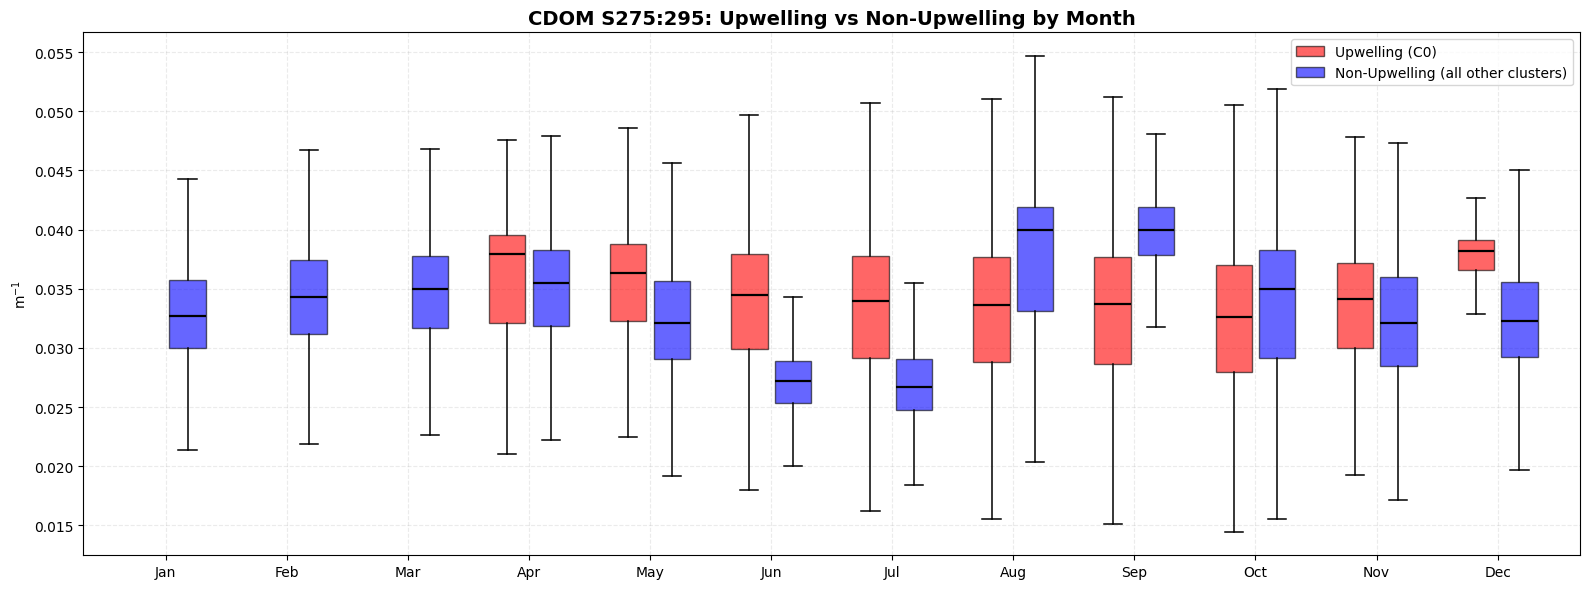

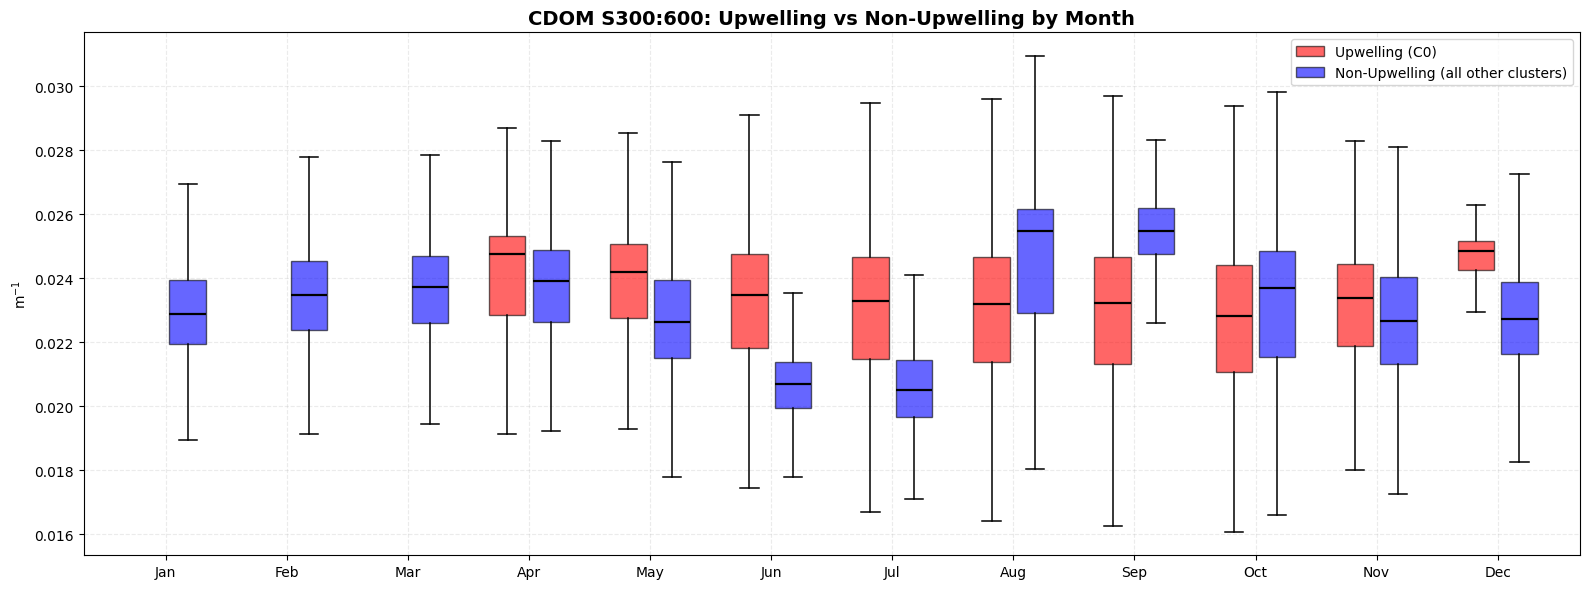

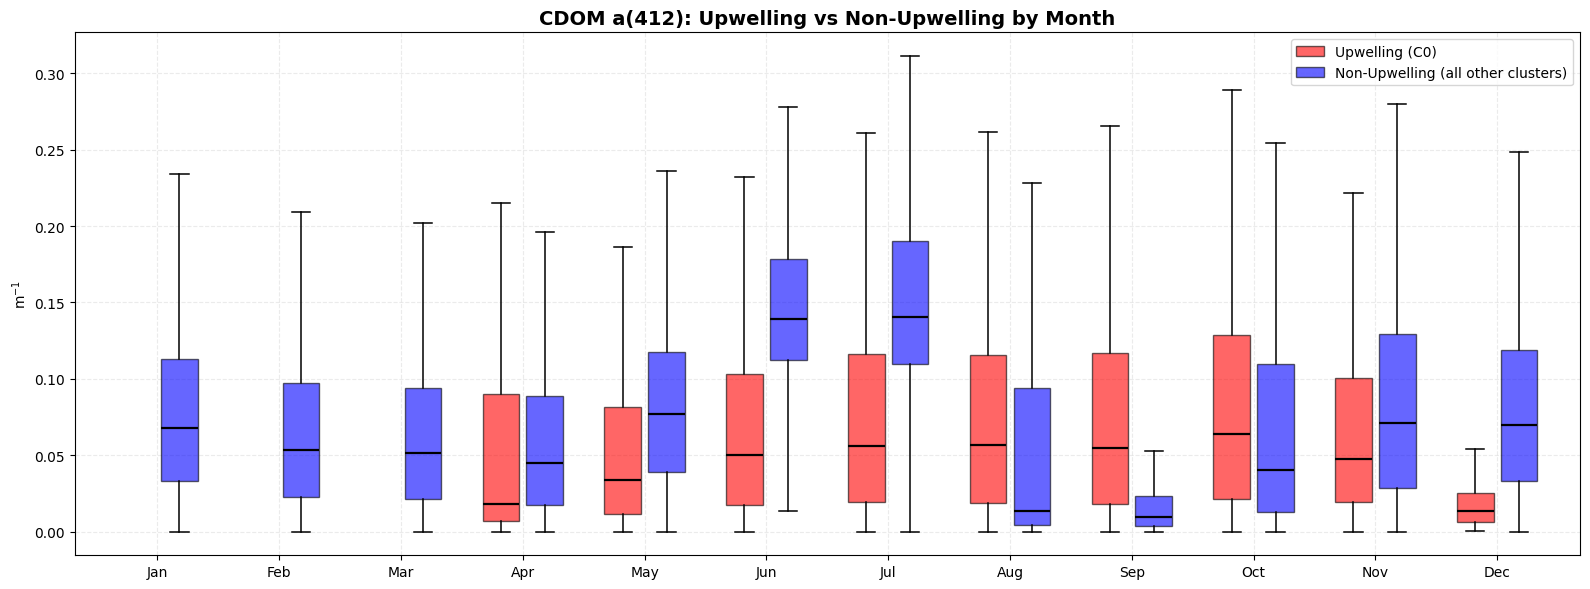

Generated 3 figures for monthly Upwelling vs Non-Upwelling CDOM comparisons.


In [8]:
# CDOM comparisons using the same trained feature pipeline
all_month_labels = []
all_month_clusters = []
all_month_s275 = []
all_month_s300 = []
all_month_a412 = []

def _is_missing_grid_local(grid_obj):
    return grid_obj is None or (isinstance(grid_obj, float) and np.isnan(grid_obj))

for date_idx, row in df.iterrows():
    month = int(date_idx.month)
    month_cont = continuous_month(date_idx)
    month_sin, month_cos = month_to_circular(month_cont)

    sst_grid = row.get('sst', np.nan)
    chlor_grid = row.get('chlorophyll', np.nan)
    ssl_grid = row.get('ssl', np.nan)
    s275_grid = row.get('cdom_slope_275_295', np.nan)
    s300_grid = row.get('cdom_slope_300_600', np.nan)
    a412_grid = row.get('cdom_412', row.get('cdom', np.nan))

    if any(_is_missing_grid_local(g) for g in [sst_grid, chlor_grid, ssl_grid, s275_grid, s300_grid, a412_grid]):
        continue

    sst_array = np.array(sst_grid, dtype=float)
    chlor_array = np.array(chlor_grid, dtype=float)
    ssl_array = np.array(ssl_grid, dtype=float)
    s275_array = np.array(s275_grid, dtype=float)
    s300_array = np.array(s300_grid, dtype=float)
    a412_array = np.array(a412_grid, dtype=float)

    ssl_nan_mask = np.isnan(ssl_array)
    if not ssl_nan_mask.all():
        ssl_filled = ssl_array.copy()
        ssl_filled[ssl_nan_mask] = np.nanmean(ssl_array)
        ssl_blurred = gaussian_filter(ssl_filled, sigma=2.0)
        ssl_blurred[ssl_nan_mask] = np.nan
        ssl_array = ssl_blurred

    sst_flat = sst_array.flatten()
    chlor_flat = chlor_array.flatten()
    ssl_flat = ssl_array.flatten()
    s275_flat = s275_array.flatten()
    s300_flat = s300_array.flatten()
    a412_flat = a412_array.flatten()

    valid_mask = (
        ~np.isnan(sst_flat)
        & ~np.isnan(chlor_flat)
        & ~np.isnan(ssl_flat)
        & ~np.isnan(s275_flat)
        & ~np.isnan(s300_flat)
        & ~np.isnan(a412_flat)
        & (chlor_flat > 0)
        & (a412_flat > 0)
    )

    if not np.any(valid_mask):
        continue

    n_valid = int(np.sum(valid_mask))
    features_all = np.column_stack([
        np.log10(chlor_flat[valid_mask]),
        sst_flat[valid_mask],
        ssl_flat[valid_mask],
        np.full(n_valid, month_sin),
        np.full(n_valid, month_cos),
    ])

    clusters_month = kmeans.predict(scaler.transform(features_all))

    all_month_labels.extend([month] * n_valid)
    all_month_clusters.extend(clusters_month)
    all_month_s275.extend(s275_flat[valid_mask])
    all_month_s300.extend(s300_flat[valid_mask])
    all_month_a412.extend(a412_flat[valid_mask])

all_month_labels = np.array(all_month_labels, dtype=int)
all_month_clusters = np.array(all_month_clusters)
all_month_s275 = np.array(all_month_s275)
all_month_s300 = np.array(all_month_s300)
all_month_a412 = np.array(all_month_a412)

if all_month_labels.size == 0:
    raise ValueError('No valid all-month pixels found for CDOM comparison.')

upwelling_cluster_id = 0
upwelling_mask = all_month_clusters == upwelling_cluster_id
non_upwelling_mask = all_month_clusters != upwelling_cluster_id
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

def plot_monthly_upwelling_vs_nonupwelling(values, var_title, y_unit):
    fig, ax = plt.subplots(figsize=(16, 6))
    up_data, non_data, up_positions, non_positions, tick_positions = [], [], [], [], []

    for month in range(1, 13):
        month_mask = all_month_labels == month
        up_vals = values[month_mask & upwelling_mask]
        non_vals = values[month_mask & non_upwelling_mask]

        if up_vals.size == 0:
            up_vals = np.array([np.nan])
        if non_vals.size == 0:
            non_vals = np.array([np.nan])

        center = month
        up_positions.append(center - 0.18)
        non_positions.append(center + 0.18)
        tick_positions.append(center)
        up_data.append(up_vals)
        non_data.append(non_vals)

    bp_up = ax.boxplot(up_data, positions=up_positions, widths=0.30, patch_artist=True, showfliers=False, medianprops={'color': 'black', 'linewidth': 1.6}, whiskerprops={'linewidth': 1.1}, capprops={'linewidth': 1.1})
    for patch in bp_up['boxes']:
        patch.set_facecolor('red')
        patch.set_alpha(0.60)
        patch.set_edgecolor('black')

    bp_non = ax.boxplot(non_data, positions=non_positions, widths=0.30, patch_artist=True, showfliers=False, medianprops={'color': 'black', 'linewidth': 1.6}, whiskerprops={'linewidth': 1.1}, capprops={'linewidth': 1.1})
    for patch in bp_non['boxes']:
        patch.set_facecolor('blue')
        patch.set_alpha(0.60)
        patch.set_edgecolor('black')

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(month_names)
    ax.set_ylabel(y_unit)
    ax.set_title(f'{var_title}: Upwelling vs Non-Upwelling by Month', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.25, linestyle='--')

    from matplotlib.patches import Patch
    legend_handles = [
        Patch(facecolor='red', edgecolor='black', alpha=0.60, label=f'Upwelling (C{upwelling_cluster_id})'),
        Patch(facecolor='blue', edgecolor='black', alpha=0.60, label='Non-Upwelling (all other clusters)'),
    ]
    ax.legend(handles=legend_handles, loc='best')
    plt.tight_layout()
    plt.show()

plot_monthly_upwelling_vs_nonupwelling(all_month_s275, 'CDOM S275:295', 'm$^{-1}$')
plot_monthly_upwelling_vs_nonupwelling(all_month_s300, 'CDOM S300:600', 'm$^{-1}$')
plot_monthly_upwelling_vs_nonupwelling(all_month_a412, 'CDOM a(412)', 'm$^{-1}$')
print('Generated 3 figures for monthly Upwelling vs Non-Upwelling CDOM comparisons.')